## Librerías.

In [1]:
import sys
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models, optimizers, regularizers
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

import matplotlib.pyplot as plt

In [2]:
from google.colab import drive
drive.mount('/content/drive')
project_path = '/content/drive/MyDrive/Redes neuronales/Tarea 7. Reconocimiento facial'
if project_path not in sys.path:
    sys.path.append(project_path)

Mounted at /content/drive


## Fine tunning.

In [42]:
# Cargamos modelo.
ruta_fase1 = os.path.join(project_path, 'models/mi_reconocedor.h5')


# Buscamos el extractor de características.
feature_extractor = None
for layer in model.layers:
    if isinstance(layer, tf.keras.Sequential):
        feature_extractor = layer
        break

if feature_extractor:
    print(f"Extractor base encontrado: {feature_extractor.name}")
    feature_extractor.trainable = True

    # Entrenamos solo las últimas capas.
    capas_a_entrenar = 3
    for layer in feature_extractor.layers[:-capas_a_entrenar]:
        layer.trainable = False

Extractor base encontrado: sequential_6


In [43]:
# Recompilamos.
model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy'])

ruta_final_refinado = os.path.join(project_path, 'models/mi_reconocedor_refinado_1.h5')

checkpoint_fino = ModelCheckpoint(
    filepath=ruta_final_refinado,
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1)

early_stop_fino = EarlyStopping(
    monitor='val_accuracy',
    patience=15,
    restore_best_weights=True)

In [44]:
# Entrenamos.
history_fine = model.fit(
    train_gen,
    validation_data=valid_gen,
    epochs=40,
    callbacks=[checkpoint_fino, early_stop_fino])

Epoch 1/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 337ms/step - accuracy: 0.7030 - loss: 3.7842
Epoch 1: val_accuracy improved from -inf to 0.77778, saving model to /content/drive/MyDrive/Redes neuronales/Tarea 7. Reconocimiento facial/models/mi_reconocedor_refinado_1.h5


10/10 ━━━━━━━━━━━━━━━━━━━━ 9s 598ms/step - accuracy: 0.7049 - loss: 3.7831 - val_accuracy: 0.7778 - val_loss: 3.7576
Epoch 2/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - accuracy: 0.8296 - loss: 3.7188
Epoch 2: val_accuracy did not improve from 0.77778
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 248ms/step - accuracy: 0.8260 - loss: 3.7183 - val_accuracy: 0.7222 - val_loss: 3.7192
Epoch 3/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - accuracy: 0.8181 - loss: 3.6715
Epoch 3: val_accuracy did not improve from 0.77778
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 241ms/step - accuracy: 0.8119 - loss: 3.6719 - val_accuracy: 0.7778 - val_loss: 3.6693
Epoch 4/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step - accuracy: 0.7693 - loss: 3.6429
Epoch 4: val_accuracy did not improve from 0.77778
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 344ms/step - accuracy: 0.7759 - loss: 3.6415 - val_accuracy: 0.7778 - val_loss: 3.6252
Epoch 5/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step - accuracy: 0.7688 - loss: 3.6009
Epoch 5: val_accuracy did not impro

In [45]:
def graficar_entrenamiento(historia):
    acc = historia.history['accuracy']
    val_acc = historia.history['val_accuracy']
    loss = historia.history['loss']
    val_loss = historia.history['val_loss']

    epochs_range = range(len(acc))

    plt.figure(figsize=(14, 5))

    # Presición.
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy', color='green')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='red')
    plt.legend(loc='lower right')
    plt.title('Precisión (Accuracy)')
    plt.grid(True)
    plt.xlabel('Épocas')
    plt.ylabel('Precisión')

    # Costo.
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss', color='green')
    plt.plot(epochs_range, val_loss, label='Validation Loss', color='red')
    plt.legend(loc='upper right')
    plt.title('Costo (Loss)')
    plt.grid(True)
    plt.xlabel('Épocas')
    plt.ylabel('Loss')

    plt.show()

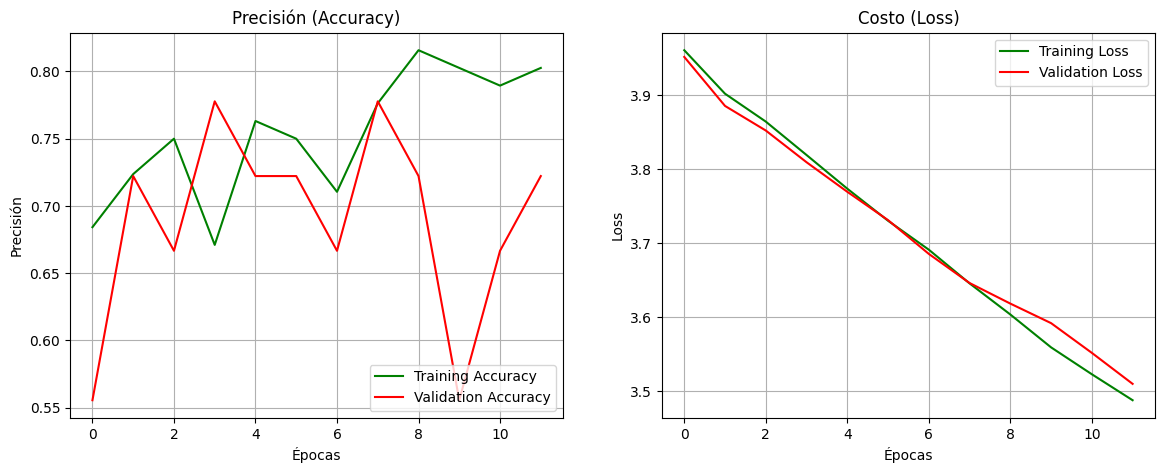

In [41]:
# Graficamos.
graficar_entrenamiento(history_fine)